In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import openml
import pandas as pd
import ipywidgets as widgets
from tqdm import tqdm

from IPython.display import display, clear_output

from datasets import (
    preprocess_features,
    encode_and_scale_features,
    download_and_process_dataset,
    download_benchmark_suite,
    download_datasets_from_df
)

from qualities import extract_suite_qualities, get_missing_data_summary

from d2v_qualities import (
    extract_metafeatures_from_datasets,
    combine_metafeature_files,
    extract_and_combine_metafeatures
)

from runs import run_extract_runs_for_suite

from meta_learning_evaluation import run_complete_evaluation, load_target_data, plot_results

### Establish the benchmark suites 
1. Download datasets
2. Download openml qualities (dealing with missing information ???)

In [2]:
selected_suite_id = None


suites_df = openml.study.list_suites(output_format="dataframe", status="all")
suites_df["alias"] = suites_df["alias"].fillna("unnamed")


options = [(f"{alias} ({sid})", sid) for sid, alias in zip(suites_df["id"], suites_df["alias"])]


dropdown = widgets.Dropdown(
    options=options,
    description='Suite:',
    layout=widgets.Layout(width='70%')
)
output = widgets.Output()


def on_dropdown_change(change):
    global selected_suite_id
    if change['type'] == 'change' and change['name'] == 'value':
        with output:
            clear_output()
            selected_suite_id = change['new']
            selected_label = next(label for label, val in options if val == selected_suite_id)
            suite_alias = selected_label.split(' (')[0]

            print(f"Selected Suite: {suite_alias} ({selected_suite_id})")

            results = download_benchmark_suite(selected_suite_id)
            print(f"Download complete: {results['successful']}/{results['total']} successful, {results['failed']} failed")

dropdown.observe(on_dropdown_change)

In [3]:
display(dropdown, output)

Dropdown(description='Suite:', layout=Layout(width='70%'), options=(('OpenML100 (14)', 14), ('OpenML-CC18 (99)…

Output()

### Extract qualities from openml

In [4]:
df = extract_suite_qualities(selected_suite_id)
print(f"Qualities extraction finished: {len(df)} datasets processed")

Benchmark Suite: OpenML100-friendly
Initial missing data: 846/5778 (14.6%)

--- Missing Data Processing ---
Initial state: 846/5778 missing (14.6%)
After removing 14 empty columns: 90/5022 missing (1.8%)
Shape change: (54, 107) → (54, 93)
Feature quality: 93 reliable (<10% missing), 0 problematic (>50% missing)
Applying KNN imputation (k=5)...
After imputation: 0 missing values remaining
Final shape: (54, 94)
Processed qualities saved to qualities/traditional/225_qualities_processed.csv
Qualities extraction finished: 54 datasets processed


### Creating d2v meta features

In [5]:
combined_df = extract_and_combine_metafeatures()

Extracting meta-features: 100%|██████████| 54/54 [04:33<00:00,  5.07s/it]

=== Combining meta-features ===
Combined 54 files into 'qualities/d2v/test_combined_metafeatures.csv'
Final meta-features shape: (54, 32)


### Fetching runs

In [6]:
run_extract_runs_for_suite(selected_suite_id,seed = 120,api_key="c0d6200b271e73a8aec0904980876c3c") # insert random seed and openml api key

Pipeline start | suite=225, seed=120


Splitting by algorithm:  87%|████████▋ | 47/54 [05:06<00:39,  5.67s/it]

Majority Class: Support Vector Machine
Majority Class Accuracy (baseline): 48.61%
All files saved to: final
Meta-feature datasets loaded.
Shapes:
  - d2v: (72, 33)
  - traditional: (72, 108)
  - hybrid: (72, 140)

 Evaluating d2v meta-model ...
  Mean accuracy: 0.6111 ± 0.0176

 Evaluating hybrid meta-model ...
  Mean accuracy: 0.6694 ± 0.0184

 Evaluating traditional meta-model ...
  Mean accuracy: 0.6375 ± 0.0181


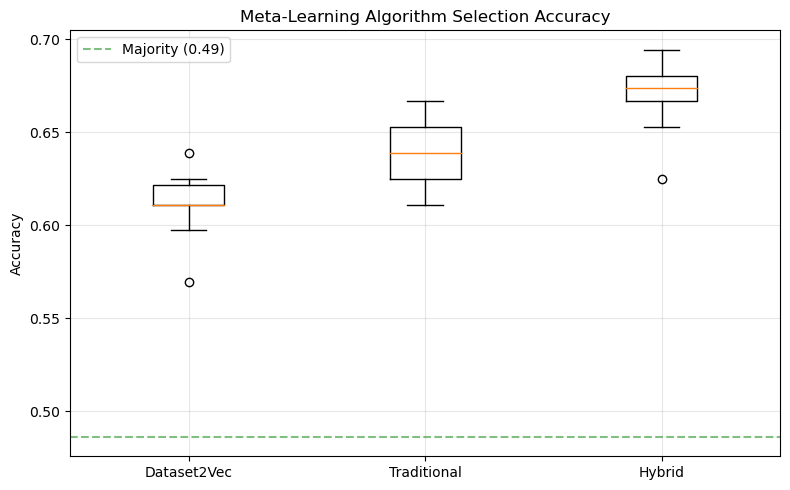


Results saved to: models_120/


In [2]:
results, majority_accuracy = run_complete_evaluation(n_repeats=10, seed=120)